# Doğrusal Regresyon

Bu notebook, doğrusal regresyon algoritmasının hem tek değişkenli hem de çok değişkenli versiyonlarını uygulamalı olarak göstermektedir. Gradient descent (dereceli alçalma) optimizasyon tekniği kullanılarak model parametreleri adım adım optimize edilmektedir.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## Tek Değişkenli Doğrusal Regresyon için Veri Seti Oluşturma

Bu bölümde, tek değişkenli doğrusal regresyon modelimizi eğitmek ve test etmek için sentetik bir veri seti oluşturacağız. Veri seti, bilinen bir doğrusal ilişkiye sahip olacak ve gerçek dünya verilerindeki rastgeleliği taklit etmek için Gauss gürültüsü eklenecektir.

**Veri Üretme Modeli:**

Veri setimiz $(X, y)$ aşağıdaki model kullanılarak üretilir:

$y^{(i)} = \theta_0 + \theta_1 x^{(i)} + \epsilon^{(i)}$

Burada:
- $x^{(i)}$: $i$-inci örneğin özellik (feature) değeri. `np.linspace` kullanılarak belirli bir aralıkta eşit aralıklı değerler olarak üretilir.
- $y^{(i)}$: $i$-inci örneğin hedef (target) değeri. Yukarıdaki formül kullanılarak hesaplanır.
- $\theta_0$: Modelin kesişim (intercept) veya bias terimi. Veri setini oluştururken bu değeri $\theta_0 = -3$ olarak ayarlıyoruz. Bu, $x=0$ olduğunda doğrunun y eksenini kestiği noktadır.
- $\theta_1$: Modelin eğim (slope) veya ağırlık (weight) katsayısı. Veri setini oluştururken bu değeri $\theta_1 = 0.5$ olarak ayarlıyoruz. Bu, $x$'deki bir birimlik artışın $y$'de ne kadar değişiklik yarattığını gösterir.
- $\epsilon^{(i)}$: $i$-inci örnek için eklenen rastgele gürültü terimi. Bu terim, ölçüm hatalarını veya model tarafından açıklanamayan diğer faktörleri temsil eder. Gürültünün ortalaması 0 ve standart sapması 0.05 olan bir Normal (Gauss) dağılımdan geldiğini varsayıyoruz: $\epsilon \sim \mathcal{N}(0, 0.05^2)$. `np.random.normal` fonksiyonu ile üretilir.

**Amaç:**

Oluşturulan $(X, y)$ veri setini kullanarak, doğrusal regresyon algoritmamızın $\theta_0$ ve $\theta_1$ parametrelerini mümkün olduğunca doğru bir şekilde tahmin etmesini sağlamaktır. Yani, modelimizin öğrenmesini istediğimiz hedef değerler $\hat{\theta}_0 \approx -3$ ve $\hat{\theta}_1 \approx 0.5$'tir.

Aşağıdaki kod hücresi, `numpy` kütüphanesini kullanarak bu veri setini oluşturacak ve ardından veriyi görselleştireceğiz.

In [5]:
ornek_sayisi = 100
theta_0 = -3
theta_1 = 0.5
X = np.linspace(-2, 2, ornek_sayisi)
y = theta_0 + (theta_1 * X) + np.random.normal(0, 0.05, size=ornek_sayisi)
print(X.shape, y.shape)

(100,) (100,)


Oluşturduğumuz verileri görselleştirelim. Bu grafik, X ve y değişkenleri arasındaki doğrusal ilişkiyi gösterir.

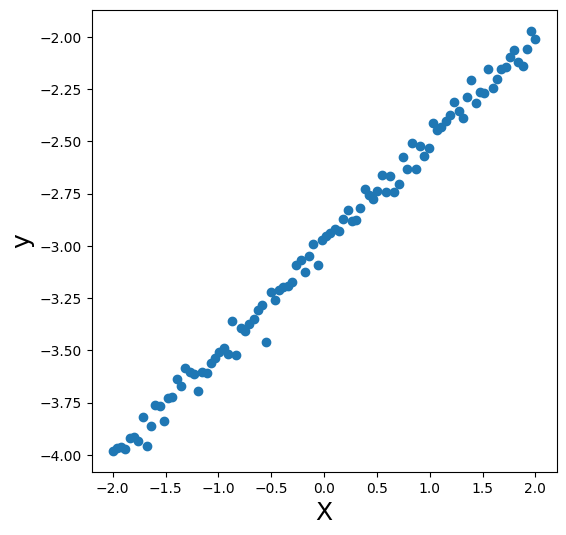

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(X, y)
plt.xlabel("X", fontsize=18)
plt.ylabel("y", fontsize=18)
plt.show()

## Eğitim ve Doğrulama Veri Setlerinin Ayrılması

Model performansını doğru bir şekilde değerlendirmek için, veri setimizi eğitim (%80) ve doğrulama (%20) olarak ikiye ayırıyoruz. Eğitim verisiyle modeli eğitecek, doğrulama verisiyle de modelin genelleme yeteneğini test edeceğiz.

In [7]:
# verileri %80 - %20 olacak şekilde eğitim ve doğrulama verisi olarak ayır
egitim_ornek_sayisi = int(ornek_sayisi * 0.8)

X_egitim, X_val = X[:egitim_ornek_sayisi], X[egitim_ornek_sayisi:]
y_egitim, y_val = y[:egitim_ornek_sayisi], y[egitim_ornek_sayisi:]

print(f"X egitim: {X_egitim.shape}, X validasyon: {X_val.shape}")
print(f"y egitim: {y_egitim.shape}, y validasyon: {y_val.shape}")

X egitim: (80,), X validasyon: (20,)
y egitim: (80,), y validasyon: (20,)


## Doğrusal Regresyon ve Dereceli Alçalma

Doğrusal regresyonda, verilen özellik (feature) değerlerine dayalı olarak hedef değişkenin değerini tahmin etmeye çalışırız. Tek değişkenli doğrusal regresyon için matematiksel model, formül ve optimizasyon sürecini aşağıda görebilirsiniz.

### Doğrusal Regresyon ve Dereceli Alçalma Adımları

**1. Hipotez Fonksiyonu:**
Modelimizin $x$ girdisi için yaptığı tahmini temsil eder. Tek değişkenli durumda:
$h_{\theta}(x) = \theta_0 + \theta_1x$
Burada $\theta_0$ kesişim (intercept) ve $\theta_1$ eğim (slope) parametreleridir.

**2. Hata Fonksiyonu (Cost Function):**
Modelimizin tahminlerinin gerçek değerlerden ($y$) ne kadar saptığını ölçer. Ortalama Kare Hata (Mean Squared Error - MSE) kullanılır. $m$ örnek sayısı olmak üzere:
$J(\theta_0, \theta_1) = \frac{1}{2m} \sum\limits_{i=1}^m (h_{\theta}(x^{(i)}) - y^{(i)})^2$
Hipotez fonksiyonunu yerine koyarsak:
$J(\theta_0, \theta_1) = \frac{1}{2m} \sum\limits_{i=1}^m (\theta_0 + \theta_1x^{(i)} - y^{(i)})^2$
Amacımız bu $J(\theta_0, \theta_1)$ değerini minimize eden $\theta_0$ ve $\theta_1$ değerlerini bulmaktır.

**3. Dereceli Alçalma (Gradient Descent):**
Hata fonksiyonunu minimize etmek için parametreleri ($\theta_0, \theta_1$) iteratif olarak güncelleyen bir optimizasyon algoritmasıdır. Her adımda, hata fonksiyonunun negatif gradyanı yönünde küçük bir adım atılır. $\alpha$ öğrenme hızıdır (learning rate).
Güncelleme kuralı genel olarak şöyledir ($j=0$ ve $j=1$ için):
$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j}J(\theta_0, \theta_1)$

**4. Gradyanların (Türevlerin) Hesaplanması:**
Güncelleme kuralını uygulamak için hata fonksiyonunun her bir parametreye göre kısmi türevini hesaplamamız gerekir.

*   **$\theta_0$ için Kısmi Türev:**
    $\frac{\partial}{\partial \theta_0}J(\theta_0, \theta_1) = \frac{\partial}{\partial \theta_0} \left[ \frac{1}{2m} \sum\limits_{i=1}^m (\theta_0 + \theta_1x^{(i)} - y^{(i)})^2 \right]$
    Zincir kuralı kullanarak:
    $= \frac{1}{2m} \sum\limits_{i=1}^m 2 (\theta_0 + \theta_1x^{(i)} - y^{(i)}) \cdot \frac{\partial}{\partial \theta_0}(\theta_0 + \theta_1x^{(i)} - y^{(i)})$
    $= \frac{1}{m} \sum\limits_{i=1}^m (\theta_0 + \theta_1x^{(i)} - y^{(i)}) \cdot 1$
    $= \frac{1}{m} \sum\limits_{i=1}^m (h_{\theta}(x^{(i)}) - y^{(i)})$

*   **$\theta_1$ için Kısmi Türev:**
    $\frac{\partial}{\partial \theta_1}J(\theta_0, \theta_1) = \frac{\partial}{\partial \theta_1} \left[ \frac{1}{2m} \sum\limits_{i=1}^m (\theta_0 + \theta_1x^{(i)} - y^{(i)})^2 \right]$
    Zincir kuralı kullanarak:
    $= \frac{1}{2m} \sum\limits_{i=1}^m 2 (\theta_0 + \theta_1x^{(i)} - y^{(i)}) \cdot \frac{\partial}{\partial \theta_1}(\theta_0 + \theta_1x^{(i)} - y^{(i)})$
    $= \frac{1}{m} \sum\limits_{i=1}^m (\theta_0 + \theta_1x^{(i)} - y^{(i)}) \cdot x^{(i)}$
    $= \frac{1}{m} \sum\limits_{i=1}^m (h_{\theta}(x^{(i)}) - y^{(i)}) \cdot x^{(i)}$

**5. Parametre Güncelleme Kuralları:**
Hesaplanan türevleri genel güncelleme kuralına yerleştirirsek:

*   **$\theta_0$ Güncellemesi:**
    $\theta_0 := \theta_0 - \alpha \frac{1}{m} \sum\limits_{i=1}^m (h_{\theta}(x^{(i)}) - y^{(i)})$

*   **$\theta_1$ Güncellemesi:**
    $\theta_1 := \theta_1 - \alpha \frac{1}{m} \sum\limits_{i=1}^m (h_{\theta}(x^{(i)}) - y^{(i)}) \cdot x^{(i)}$

Bu iki güncelleme kuralı, her iterasyonda **eş zamanlı** olarak uygulanır. Algoritma, parametreler yakınsayana veya belirli bir iterasyon sayısına ulaşılana kadar tekrarlanır.


## Tek Özellik (Feature) için Doğrusal Regresyon Sınıfı

Aşağıda, tek bir özellik için doğrusal regresyon modeli oluşturan bir sınıf tanımlıyoruz. Bu sınıf:
- Gradient descent algoritmasını kullanarak $\theta_0$ ve $\theta_1$ parametrelerini optimize eder
- Eğitim sürecinde modelin gelişimini görselleştirir (her 50 iterasyonda bir)

In [8]:
# https://github.com/python-engineer/MLfromscratch/ adresindeki örnekten uyarlanmıştır.


def hata_fonksiyonu(y_gercek, y_tahmin):
    ornek_sayisi = len(y_gercek)
    hata = 1 / (2 * ornek_sayisi) * np.sum((y_tahmin - y_gercek) ** 2)
    return hata


class LinearRegression_1_feature:
    def __init__(self, ogrenme_hizi):
        self.ogrenme_hizi = ogrenme_hizi
        self.theta_0 = None
        self.theta_1 = None

    def fit(self, X, y, tekrar_sayisi):
        ornek_sayisi = len(X)

        # parametrelere ilk değerlerini ata
        self.theta_0 = 0
        self.theta_1 = 0

        # grafiği hazırla
        plt.figure(figsize=(8, 8))
        plt.scatter(X, y)
        plt.xlabel("X", fontsize=18)
        plt.ylabel("y", fontsize=18)

        hatalar = []

        # gradient descent
        for i in range(tekrar_sayisi):
            y_tahmin = self.theta_0 + (self.theta_1 * X)

            # türevleri hesapla
            d_theta_0 = (1 / ornek_sayisi) * np.sum(y_tahmin - y)
            d_theta_1 = (1 / ornek_sayisi) * np.dot(X.T, (y_tahmin - y))

            # parametreleri güncelle
            self.theta_0 = self.theta_0 - self.ogrenme_hizi * d_theta_0
            self.theta_1 = self.theta_1 - self.ogrenme_hizi * d_theta_1

            # her 50 döngüde bir tahmin grafiğini göster
            if i % 50 == 0:
                plt.plot(X, y_tahmin)
                hata = hata_fonksiyonu(y, y_tahmin)
                hatalar.append(hata)

        plt.show()
        return hatalar

    def predict(self, X):
        y_tahmin = self.theta_0 + (self.theta_1 * X)
        return y_tahmin

    def get_params(self):
        return self.theta_0, self.theta_1


## Model Oluşturma ve Eğitme

Şimdi, tanımladığımız sınıfı kullanarak bir model oluşturacak ve eğitim verileri üzerinde eğiteceğiz.

In [9]:
model = LinearRegression_1_feature(0.01)
model_variant_demo = LinearRegression_1_feature(0.0005)

Modeli eğitim veri seti üzerinde 1000 iterasyon boyunca eğitiyoruz. Her 50 iterasyonda bir modelin tahminleri grafikte gösterilir ve hata değeri kaydedilir.

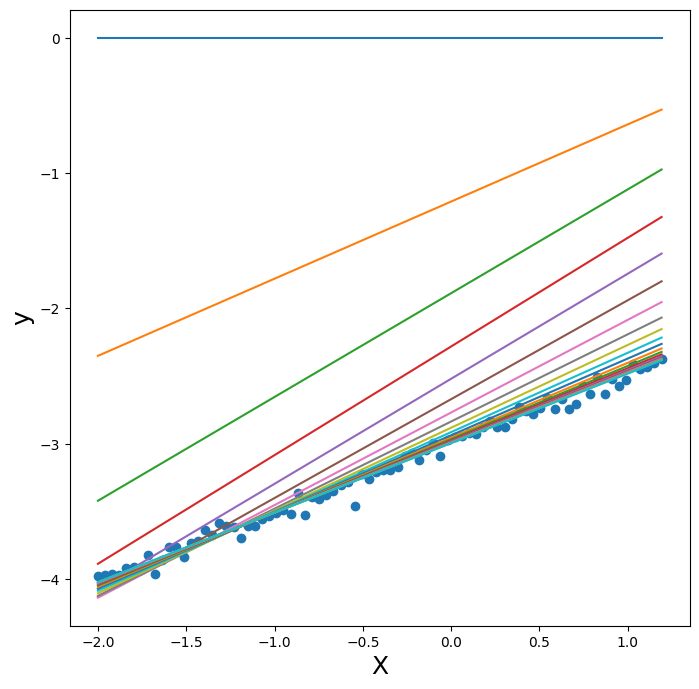

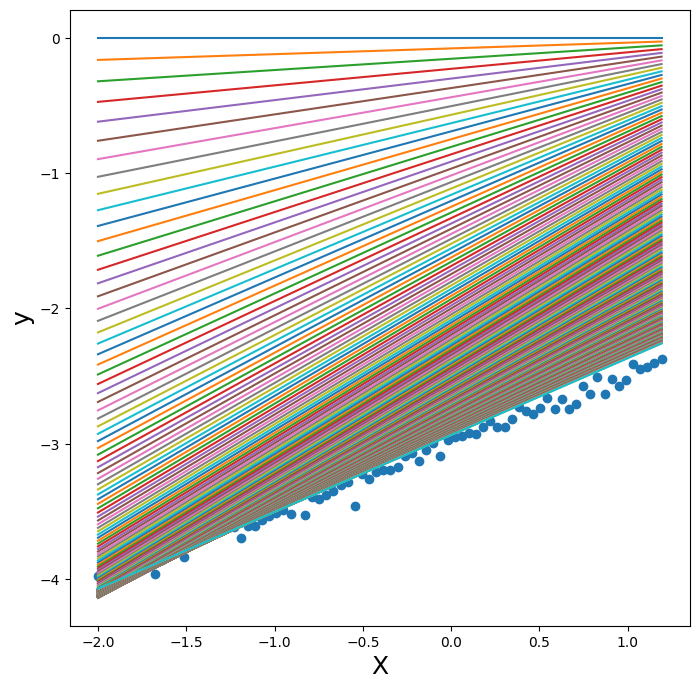

In [10]:
hatalar = model.fit(X_egitim, y_egitim, 1000)
hatalar_variant_005 = model_variant_demo.fit(X_egitim, y_egitim, 10000)

## Hata Eğrisi

Eğitim sırasında kaydedilen hata değerlerini zaman içinde grafiğe çizelim. Bu grafik, modelimizin eğitim sırasında nasıl geliştiğini gösterir.

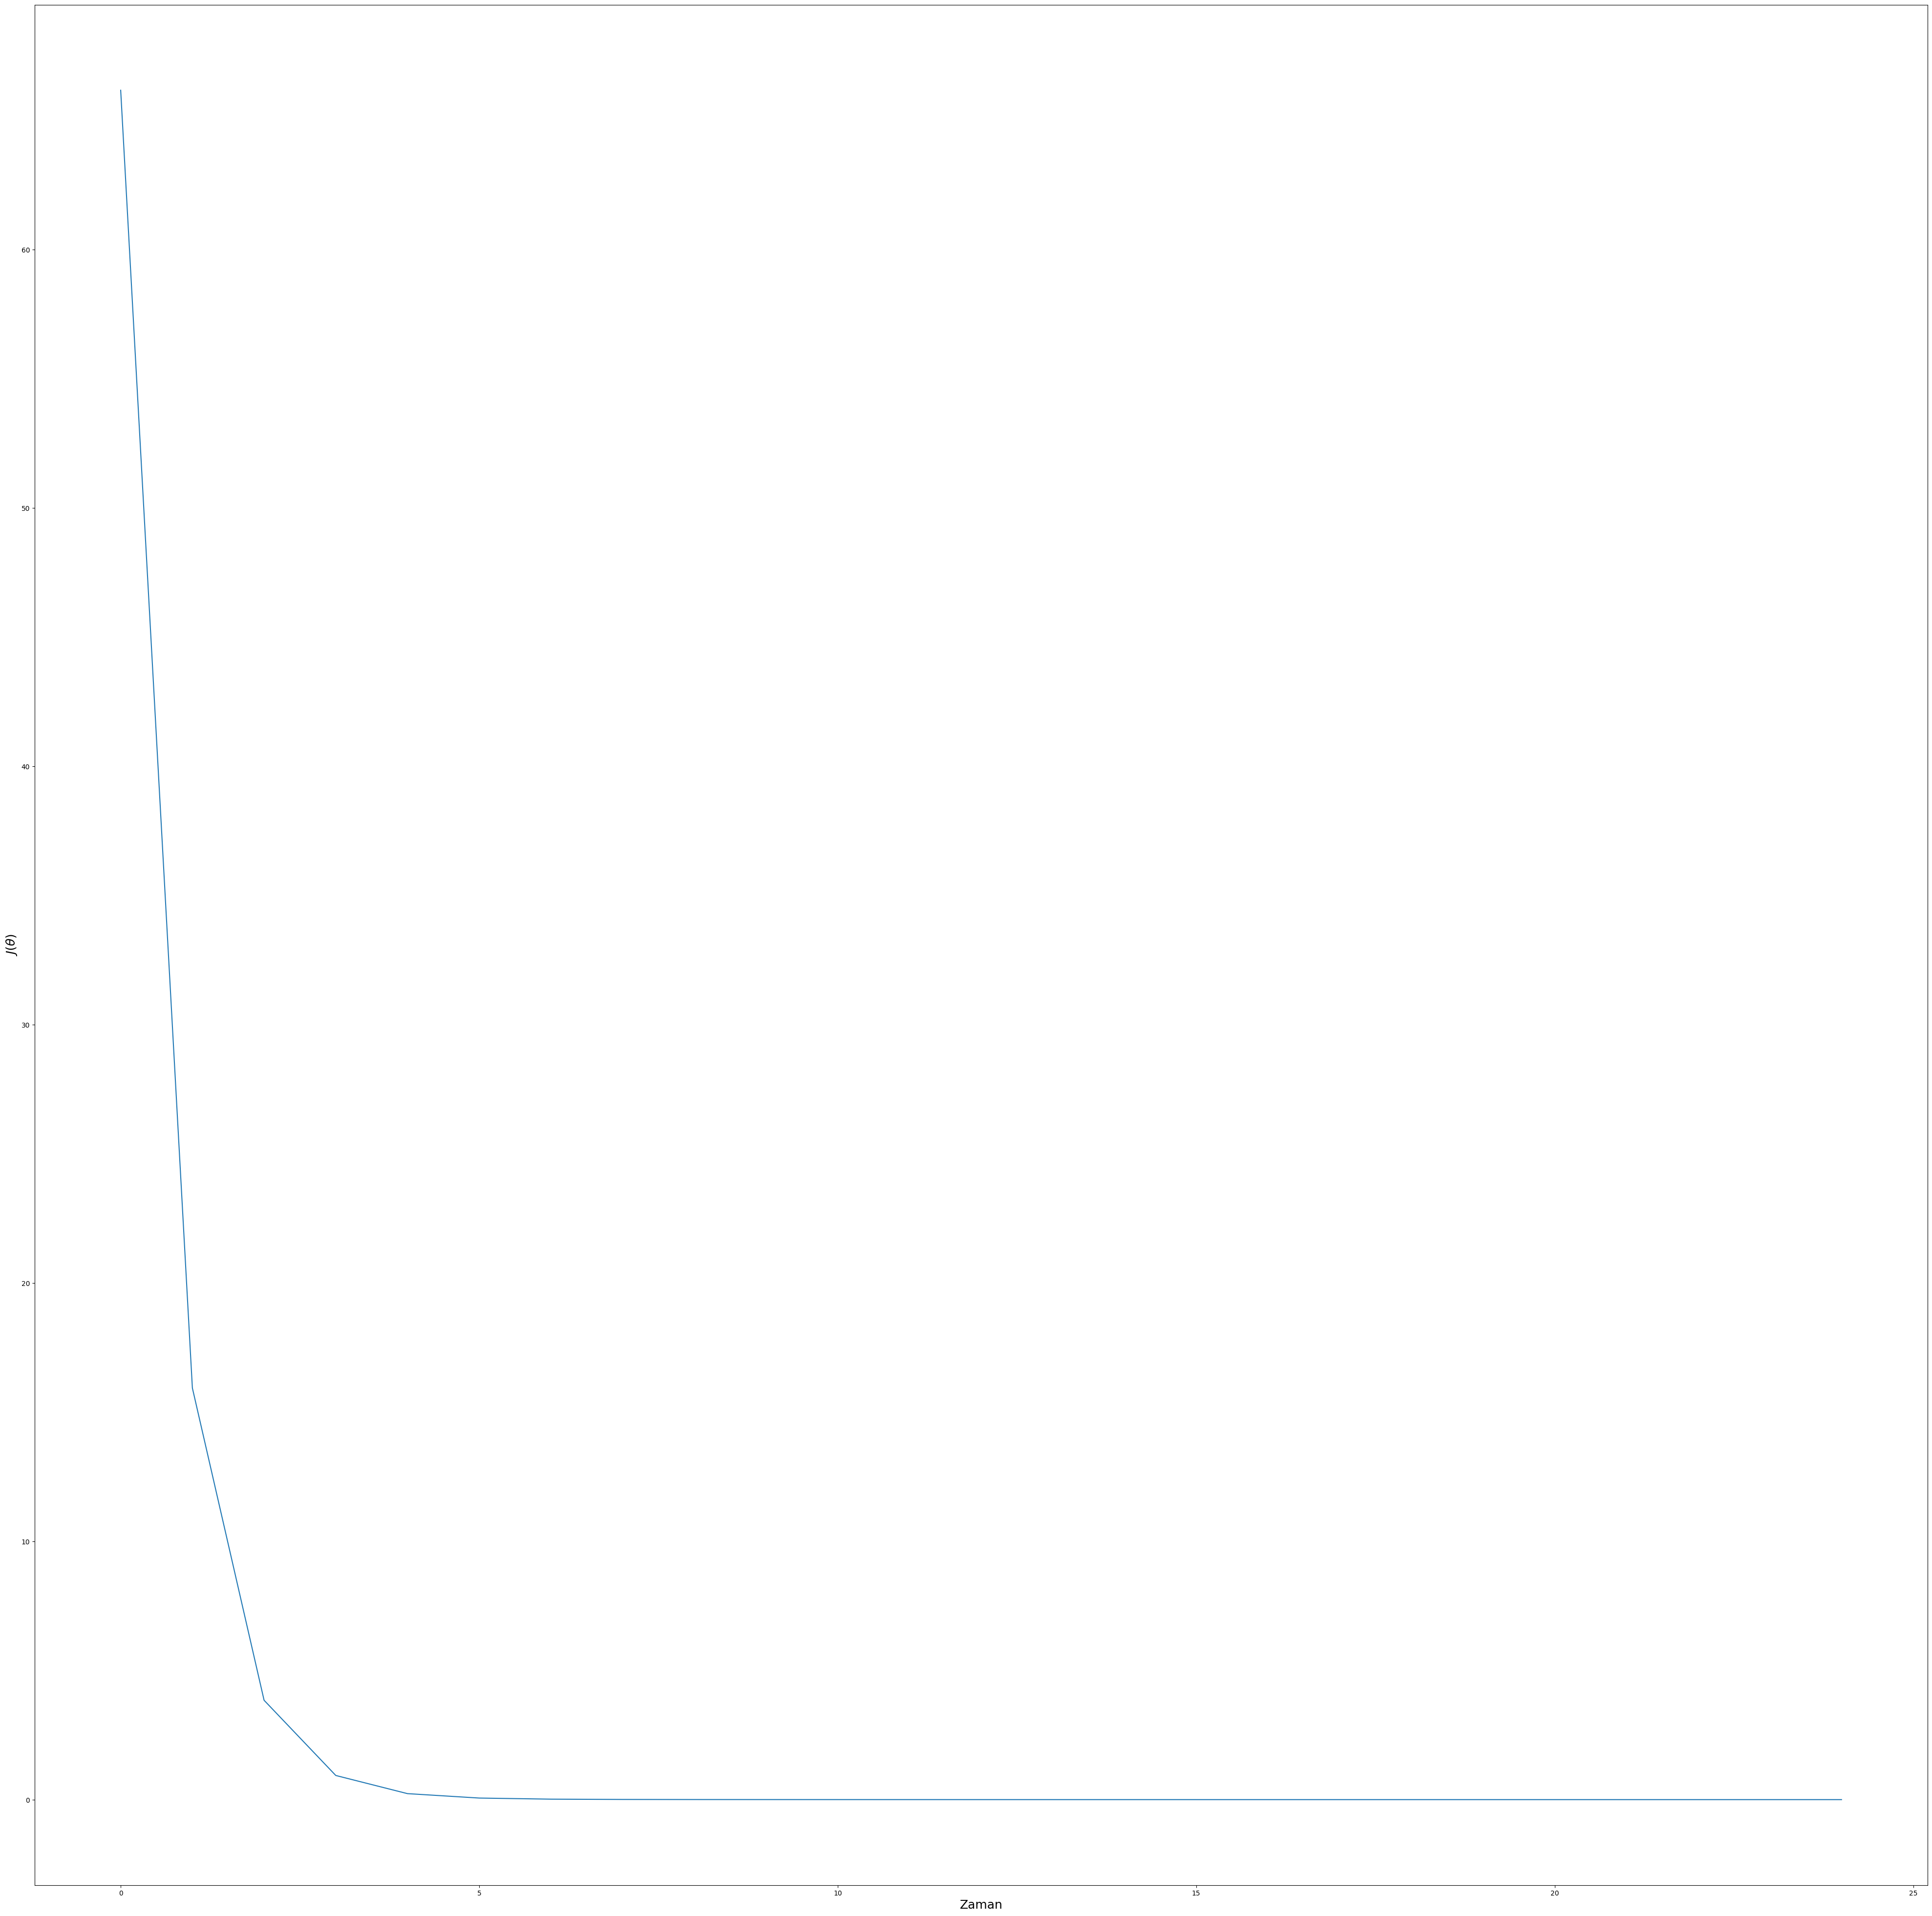

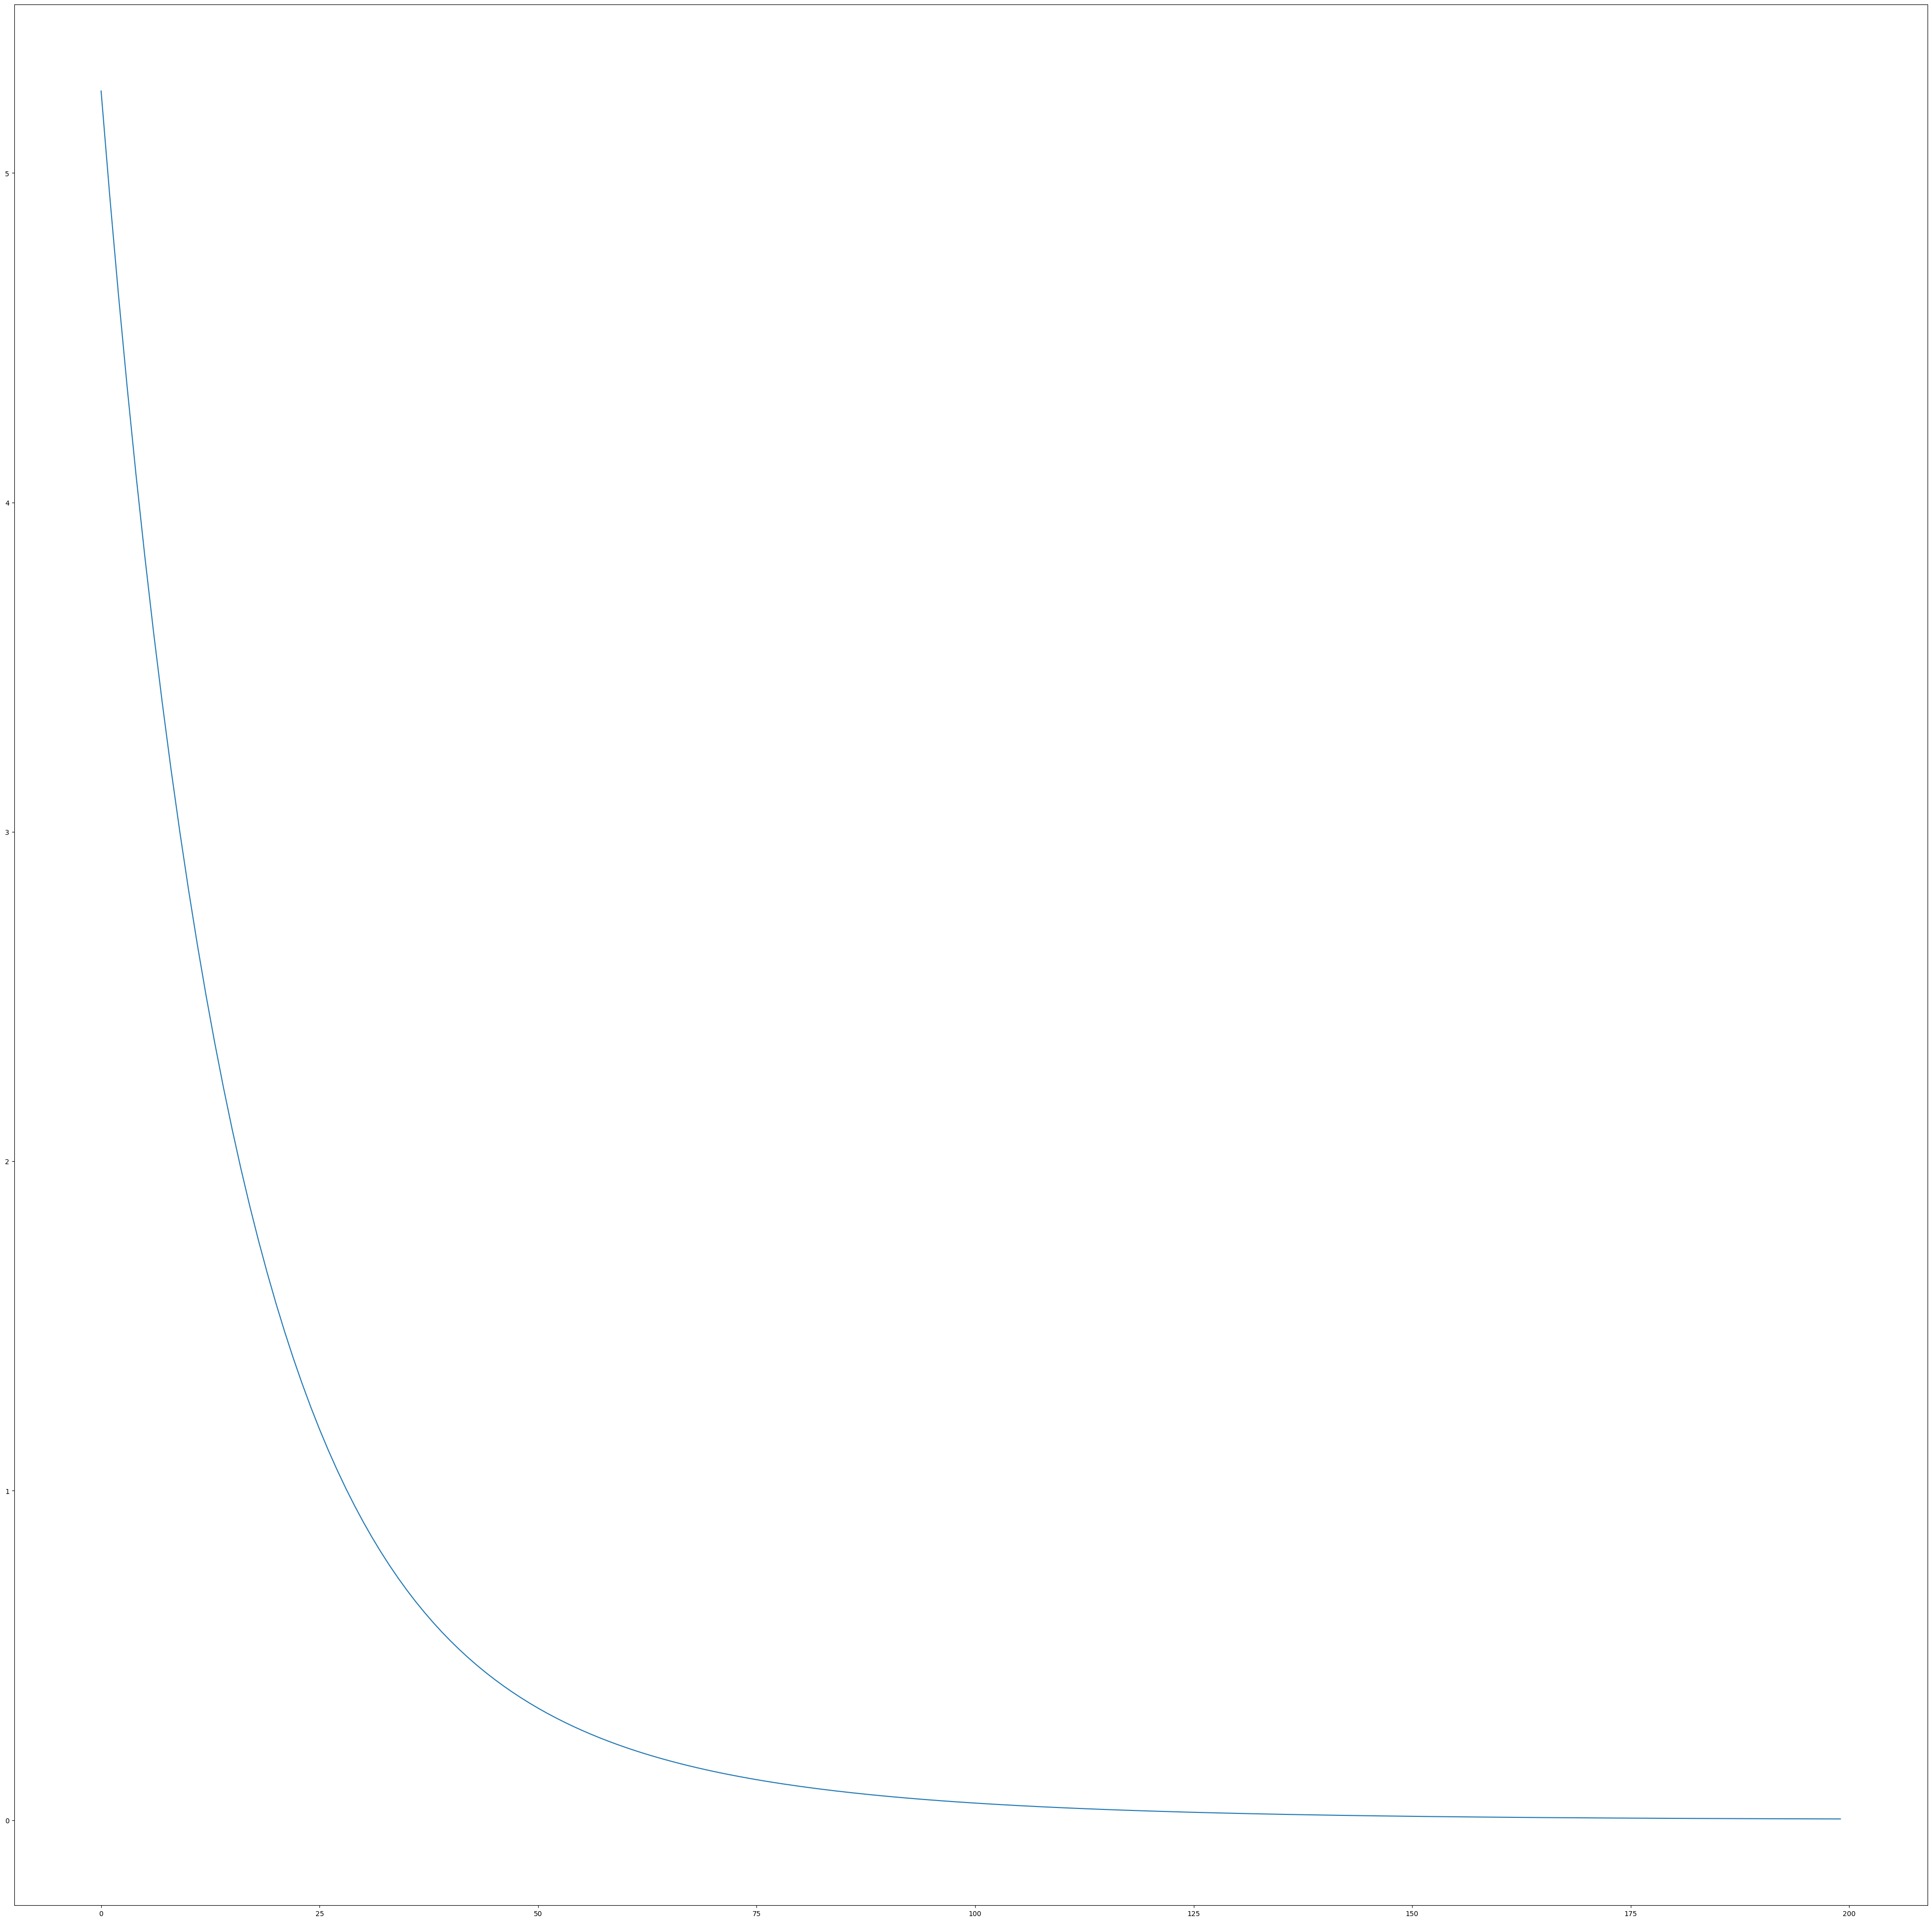

In [26]:
plt.figure(figsize=(50, 50))
plt.plot(range(len(hatalar)), hatalar)

plt.xlabel("Zaman", fontsize=18)
plt.ylabel(r"$J(\theta)$", fontsize=18)
plt.show()
plt.figure(figsize=(50, 50))
plt.plot(range(len(hatalar_variant_005)), hatalar_variant_005)

## Eğitilmiş Model

Eğitilen modelimizin, eğitim veri seti üzerindeki performansını görselleştirelim. Kırmızı çizgi, modelimizin tahminlerini gösterir.

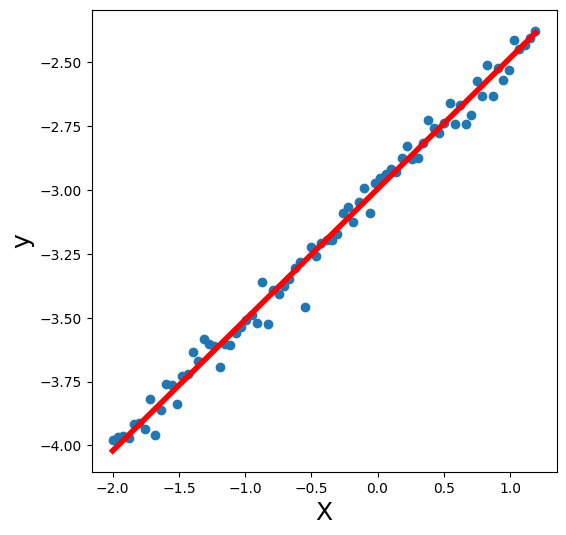

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(X_egitim, y_egitim)

plt.xlabel("X", fontsize=18)
plt.ylabel("y", fontsize=18)

y_tahmin = model.predict(X_egitim)
plt.plot(X_egitim, y_tahmin, color="red", linewidth=4)

plt.show()

## Model Doğrulama (Validasyon)

Şimdi, eğitilmiş modelimizi daha önce görmediği doğrulama verisi üzerinde test edelim. Bu, modelimizin genelleme yeteneğini değerlendirmemize yardımcı olur.

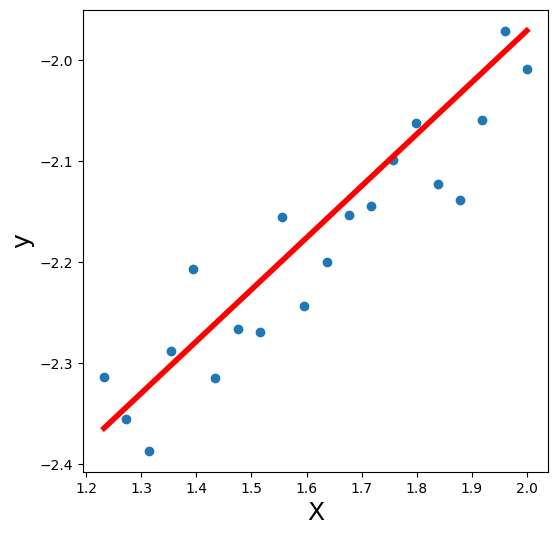

In [28]:
plt.figure(figsize=(6, 6))
plt.scatter(X_val, y_val)

plt.xlabel("X", fontsize=18)
plt.ylabel("y", fontsize=18)

plt.plot(X_val, model.predict(X_val), color="red", linewidth=4)

plt.show()

## Model Performansının Değerlendirilmesi

Model performansını değerlendirmek için Ortalama Kare Hata (Mean Squared Error - MSE) metriğini kullanacağız.

In [30]:
def mean_squared_error(y_gercek, y_tahmin):
    return np.mean((y_gercek - y_tahmin) ** 2)

In [31]:
print(f"MSE: {mean_squared_error(y_val, model.predict(X_val))}")

MSE: 0.002391228307984841


Modelimizin öğrendiği parametreleri alalım. Bunların, veri setini oluştururken kullandığımız gerçek değerlere ($\theta_0 = -3$ ve $\theta_1 = 0.5$) ne kadar yakın olduğunu görebiliriz.

In [32]:
print(f"Modelin öğrendiği parametreler: {model.get_params()}")

Modelin öğrendiği parametreler: (np.float64(-2.995858705549716), np.float64(0.5124225884593976))


# Çok Değişkenli Doğrusal Regresyon

Şimdi, birden fazla özelliğe (feature) sahip veriler için doğrusal regresyon modelini uygulayacağız. Bu durumda, hedef değişken ($y$) birden fazla girdi özelliğinin ($x_1, x_2, ..., x_n$) doğrusal bir kombinasyonu olarak modellenir.

## Veri Seti Hazırlama

Çok değişkenli doğrusal regresyon için sentetik bir veri seti oluşturacağız.

**Matematiksel Model:**

$n$ tane özelliğimiz olduğunu varsayalım. $i$-inci örnek için hipotez fonksiyonumuz $h_\theta(x^{(i)})$ şu şekilde tanımlanır:

$h_\theta(x^{(i)}) = \theta_0 x_0^{(i)} + \theta_1 x_1^{(i)} + \theta_2 x_2^{(i)} + ... + \theta_n x_n^{(i)}$

Burada:
- $x^{(i)} = [x_0^{(i)}, x_1^{(i)}, ..., x_n^{(i)}]$ $i$-inci örneğin özellik vektörüdür.
- $x_0^{(i)}$ genellikle 1 olarak alınır ve bias (kesişim) terimine karşılık gelir.
- $\theta = [\theta_0, \theta_1, ..., \theta_n]$ modelin parametre (ağırlık) vektörüdür.

Vektör gösterimiyle hipotez fonksiyonu daha kompakt bir şekilde ifade edilebilir:

$h_\theta(x^{(i)}) = (\theta^T x^{(i)})^T = (x^{(i)})^T \theta$

Tüm veri seti için ($m$ örnek) matris formunda yazarsak:

$h_\theta(X) = X \theta$

Burada $X$, $m \times (n+1)$ boyutlu özellik matrisidir (her satır bir örnektir ve ilk sütun 1'lerden oluşur) ve $\theta$, $(n+1) \times 1$ boyutlu parametre vektörüdür.

**Sentetik Veri Üretimi:**

Bu notebook'ta, $n=2$ özellikli bir durum için veri üreteceğiz. Yani modelimiz:

$y^{(i)} = \theta_0 x_0^{(i)} + \theta_1 x_1^{(i)} + \theta_2 x_2^{(i)}$

Veri setini oluştururken aşağıdaki gerçek parametre değerlerini kullanacağız:

$\theta = [\theta_0, \theta_1, \theta_2] = [3, -2, 5]$

Özellik matrisi $X$'i şu şekilde oluşturacağız:
- İlk sütun ($x_0$) tamamen 1'lerden oluşacak (bias terimi).
- İkinci sütun ($x_1$) `np.linspace(-2, 1, ornek_sayisi)` ile oluşturulacak.
- Üçüncü sütun ($x_2$) `np.linspace(1, 2, ornek_sayisi)` ile oluşturulacak.

Hedef vektör $y$ ise aşağıdaki formülle hesaplanacaktır (bu örnekte gürültü eklenmemiştir):

$y = X \theta^T$

Amacımız, oluşturulan bu $(X, y)$ veri setini kullanarak, çok değişkenli doğrusal regresyon algoritmamızın $\theta$ vektörünü (yani $\theta_0, \theta_1, \theta_2$ değerlerini) mümkün olduğunca doğru bir şekilde tahmin etmesini sağlamaktır.

In [ ]:
ornek_sayisi = 100
theta_arr = np.array([3, -2, 5])


X = np.ones((ornek_sayisi, 3))
X[:,1] = np.linspace(-2, 1, ornek_sayisi).T
X[:,2] = np.linspace(1, 2, ornek_sayisi).T

y = np.dot(X, theta_arr.T)

print("İlk 5 X değeri:")
print(X[:5])
print("İlk 5 y değeri:")
print(y[:5])

İlk 5 X değeri:
[[ 1.         -2.          1.        ]
 [ 1.         -1.96969697  1.01010101]
 [ 1.         -1.93939394  1.02020202]
 [ 1.         -1.90909091  1.03030303]
 [ 1.         -1.87878788  1.04040404]]
İlk 5 y değeri:
[12.         11.98989899 11.97979798 11.96969697 11.95959596]


Verilerimizin boyutlarını kontrol edelim. X matrisimiz (100, 3) boyutunda olmalı (100 örnek, her biri 3 özellik içerir) ve y vektörümüz (100,) boyutunda olmalıdır.

In [34]:
print(X.shape, y.shape)

(100, 3) (100,)


## Çok Değişkenli Doğrusal Regresyon Sınıfı

Şimdi, çok değişkenli doğrusal regresyon için genel bir sınıf tanımlayacağız. Bu sınıf, daha önceki tek değişkenli sınıfın genelleştirilmiş halidir ve herhangi bir boyuttaki özellik vektörüyle çalışabilir.
numpy.transpose
numpy.transpose(a, axes=None)
[source]

Returns an array with axes transposed.

For a 1-D array, this returns an unchanged view of the original array, as a transposed vector is simply the same vector. To convert a 1-D array into a 2-D column vector, an additional dimension must be added, e.g., np.atleast_2d(a).T achieves this, as does a[:, np.newaxis]. For a 2-D array, this is the standard matrix transpose. For an n-D array, if axes are given, their order indicates how the axes are permuted (see Examples). If axes are not provided, then transpose(a).shape == a.shape[::-1].

Parameters:

    a
    array_like

        Input array.
    axes
    tuple or list of ints, optional

        If specified, it must be a tuple or list which contains a permutation of [0, 1, …, N-1] where N is the number of axes of a. Negative indices can also be used to specify axes. The i-th axis of the returned array will correspond to the axis numbered axes[i] of the input. If not specified, defaults to range(a.ndim)[::-1], which reverses the order of the axes.

Returns:

    p
    ndarray

        a with its axes permuted. A view is returned whenever possible.

See also

ndarray.transpose

    Equivalent method.
moveaxis

    Move axes of an array to new positions.
argsort

    Return the indices that would sort an array.

Notes

Use transpose(a, argsort(axes)) to invert the transposition of tensors when using the axes keyword argument.

Examples

import numpy as np

a = np.array([[1, 2], [3, 4]])

a
array([[1, 2],
       [3, 4]])

np.transpose(a)
array([[1, 3],
       [2, 4]])

a = np.array([1, 2, 3, 4])

a
array([1, 2, 3, 4])

np.transpose(a)
array([1, 2, 3, 4])

a = np.ones((1, 2, 3))

np.transpose(a, (1, 0, 2)).shape
(2, 1, 3)

a = np.ones((2, 3, 4, 5))

np.transpose(a).shape
(5, 4, 3, 2)

a = np.arange(3*4*5).reshape((3, 4, 5))

np.transpose(a, (-1, 0, -2)).shape
(5, 3, 4)


In [ ]:
class LinearRegression:
    def __init__(self, ogrenme_hizi):
        self.ogrenme_hizi = ogrenme_hizi
        self.thetalar = None

    def fit(self, X, y, tekrar_sayisi):
        ornek_sayisi, feature_sayisi = X.shape

        # parametrelere ilk değerlerini ata
        self.thetalar = np.zeros(feature_sayisi)
        hatalar = []

        # gradient descent
        for i in range(tekrar_sayisi):
            y_tahmin = np.dot(X, self.thetalar.T)

            # türevleri hesapla
            d_thetalar = (1 / ornek_sayisi) * np.dot(X.T, (y_tahmin - y))

            # parametreleri güncelle
            self.thetalar = self.thetalar - self.ogrenme_hizi * d_thetalar

            # her 20 döngüde bir hatayı kaydet
            if i % 20 == 0:
                hata = hata_fonksiyonu(y, y_tahmin)
                hatalar.append(hata)

        return hatalar

    def predict(self, X):
        y_tahmin = np.dot(X, self.thetalar.T)
        return y_tahmin

    def get_params(self):
        return self.thetalar

## Çok Değişkenli Model Eğitimi

Çok değişkenli doğrusal regresyon modelimizi oluşturuyoruz ve eğitim verisi üzerinde eğitiyoruz.

In [35]:
lr_model = LinearRegression(0.01)
hatalar = lr_model.fit(X, y, 500)

## Hata Eğrisi (Çok Değişkenli Model)

Çok değişkenli modelimizin eğitim sırasındaki hata değerlerinin değişimini grafiğe çizelim.

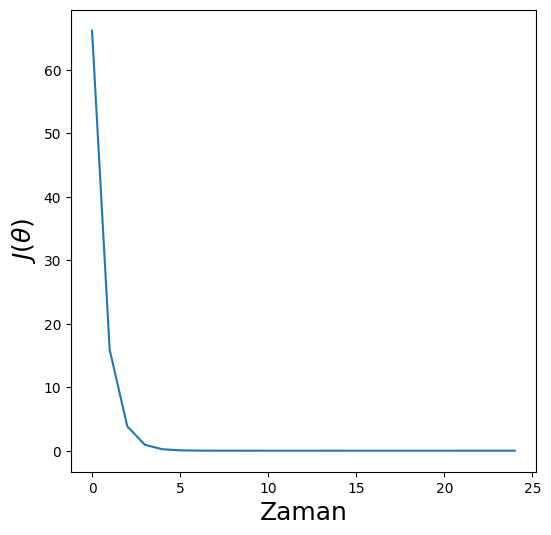

In [36]:
plt.figure(figsize=(6, 6))
plt.plot(range(len(hatalar)), hatalar)
plt.xlabel("Zaman", fontsize=18)
plt.ylabel(r"$J(\theta)$", fontsize=18)
plt.show()

## Öğrenilen Parametreler (Çok Değişkenli Model)

Çok değişkenli modelimizin öğrendiği parametreleri görüntüleyelim ve bunları gerçek değerlerle ([3, -2, 5]) karşılaştıralım.

In [22]:
print("Öğrenilen Theta değerleri (doğru değerler: [3, -2, 5]:")
print(lr_model.get_params())

Öğrenilen Theta değerleri (doğru değerler: [3, -2, 5]:
[ 3.28571423 -1.93865844  4.8299709 ]
